<a href="https://colab.research.google.com/github/nanduvarghese-glitch/gen-ai/blob/main/project_image_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
zip_path = "/content/archive (3).zip"

In [13]:
import zipfile
import os

zip_path = "/content/archive (3).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

Dataset extracted to: /content/dataset


In [15]:
from glob import glob

image_paths = glob("/content/dataset/**/*.png", recursive=True)
print("Total Images:", len(image_paths))

Total Images: 0


In [16]:
import os
import cv2
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from glob import glob
from PIL import Image

In [17]:
zip_path = "/content/archive (3).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [18]:

extensions = ['*.jpg','*.jpeg','*.png','*.bmp']

image_paths = []

for ext in extensions:
    image_paths.extend(
        glob(os.path.join(extract_path,'**',ext), recursive=True)
    )

print("Total Images:", len(image_paths))

Total Images: 2074


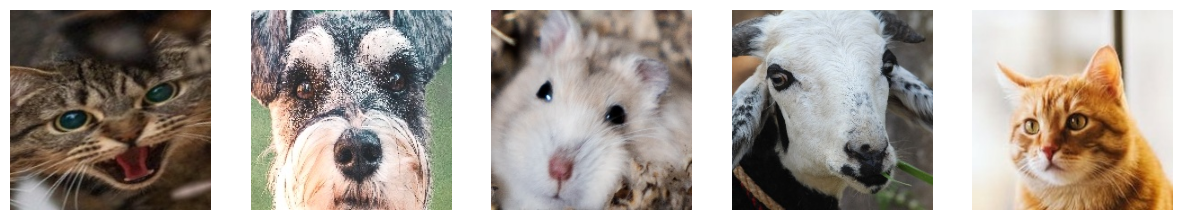

In [19]:

plt.figure(figsize=(15,5))

for i in range(5):
    img = cv2.imread(image_paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [20]:
data = []

for path in image_paths:
    img = cv2.imread(path)

    if img is not None:
        h,w,c = img.shape

        data.append([
            os.path.basename(path),
            h,
            w,
            c
        ])

df = pd.DataFrame(
    data,
    columns=["Image","Height","Width","Channels"]
)

df.head()

,Image,Height,Width,Channels
0,aug-29-38.jpg,224,224,3
1,aug-127-69.jpg,179,179,3
2,79.jpg,224,224,3
3,85.jpg,224,224,3
4,06.jpg,224,224,3


In [21]:
df.to_csv("image_dimensions.csv", index=False)

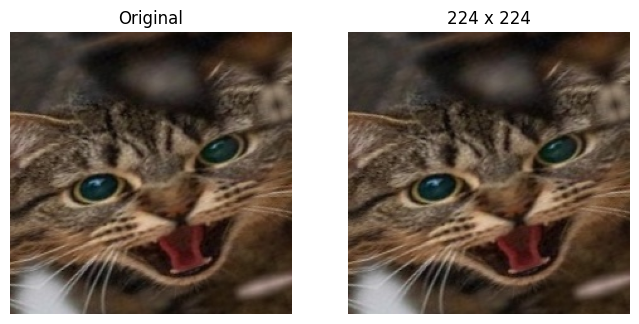

In [22]:
sample = cv2.imread(image_paths[0])

sample_rgb = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)

resized = cv2.resize(sample_rgb,(224,224))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(resized)
plt.title("224 x 224")
plt.axis("off")

plt.show()

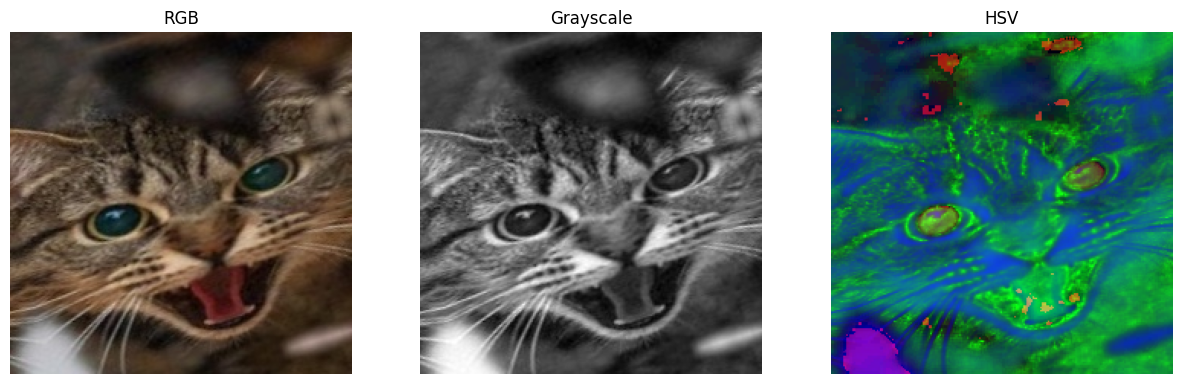

In [23]:
gray = cv2.cvtColor(sample_rgb, cv2.COLOR_RGB2GRAY)
hsv = cv2.cvtColor(sample_rgb, cv2.COLOR_RGB2HSV)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(sample_rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray,cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(hsv)
plt.title("HSV")
plt.axis("off")

plt.show()


In [24]:
normalized = sample_rgb / 255.0

print("Before Normalization")
print("Min:", sample_rgb.min())
print("Max:", sample_rgb.max())

print("\nAfter Normalization")
print("Min:", normalized.min())
print("Max:", normalized.max())

Before Normalization
Min: 0
Max: 225

After Normalization
Min: 0.0
Max: 0.8823529411764706


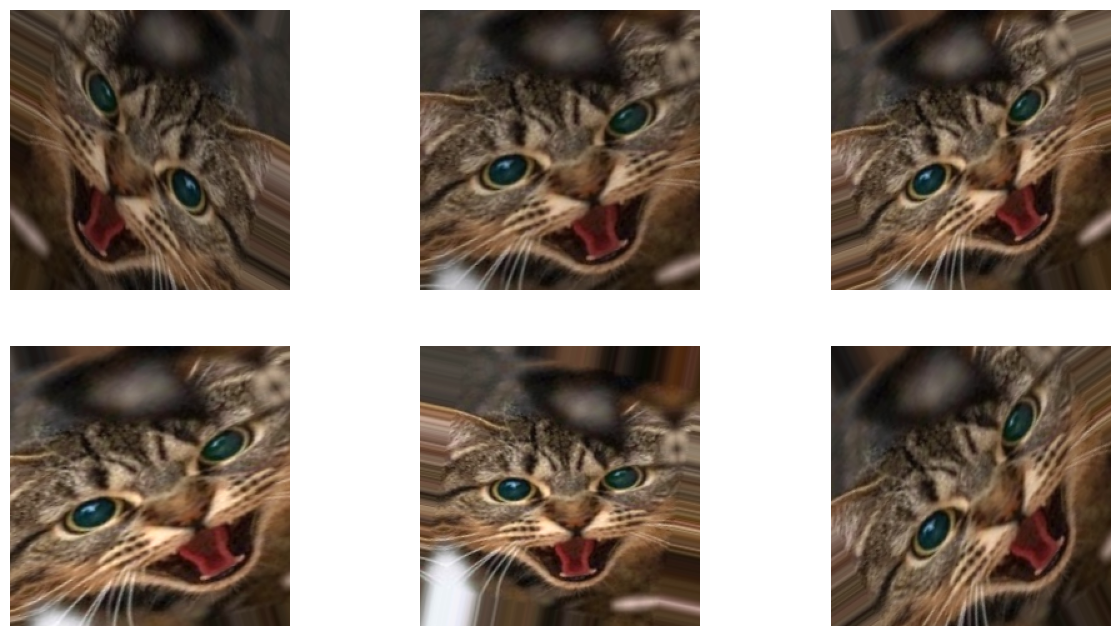

In [28]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.7,1.3]
)

img = cv2.resize(sample_rgb,(224,224))
img = np.expand_dims(img,axis=0)

aug_iter = datagen.flow(img,batch_size=1)

plt.figure(figsize=(15,8))

for i in range(6):

    batch = next(aug_iter)

    plt.subplot(2,3,i+1)
    plt.imshow(batch[0].astype(np.uint8))
    plt.axis("off")

plt.show()

In [29]:
def preprocess_image(image_path):

    img = cv2.imread(image_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img = cv2.resize(
        img,
        (224,224)
    )

    img = img / 255.0

    img = cv2.GaussianBlur(
        img,
        (5,5),
        0
    )

    return img

processed = preprocess_image(
    image_paths[0]
)

print("Processed Shape:", processed.shape)

Processed Shape: (224, 224, 3)
